<div class="alert alert-block alert-info" >
    <h1>Machine Learning: Assignment 2</h1>
    <h2>This is a two week assignment</h2>
    <h3>General Information:</h3>
    <p>Feel free to add cells if required.<br> Feel free to write your own function block to reduce the redundancy.<br> Answers belong into the corresponding cells (below the question). <br><br> If you encounter empty cells underneath the answer that can not be edited, please ignore them, they are for testing purposes.<br><br>When editing an assignment there can be the case that there are variables in the kernel. To make sure your assignment works, please restart the kernel and run all cells before submitting (e.g. via <i>Kernel -> Restart & Run All</i>). We don't consider that respective solution if you make this mistake (no excuse).</p>
    <br><br><b> Give proper comments, follow camel case for the function name, use proper readable variable names to your coding, if you didn't follow the instructions there will be a reduction in the points</b><br><br>    
    <h3>Submission:</h3>
    <p>Use the following naming convention for your submissions: LA_FirstnameLastname_dateOfLecture, e.g LA_JohnDoe_YYMMDD
     <br><br>Please submit your notebook via LEA. The assignment is due on <b>$21^{st}$ November, Saturday at 20:00.</b> </p>
    <h3>Group Work:</h3>
    <p>You are allowed to work in groups of up to two people. Please enter the UID (your username here) of each member of the group into the next cell. We apply plagiarism checking, so do not submit solutions from other people except your team members. If an assignment has a copied solution, the task will be graded with 0 points for all people with the same solution.</p>
    <p><b>YOU SHOULD ONLY SUBMIT EXACTLY ONE PER GROUP</b></p>
    <h3>Questions about the Assignment:</h3>
    <p>If you have questions about the assignment please post them in the LEA forum before the deadline. Don't wait until the last day to post questions.</p></div>

In [1]:
'''
Group Work:
Enter the UID (i.e. student2s) of each team member into the variables. 
If you work alone please leave the second variable empty, or extend the list if necessary.
'''
member1 = 'g_vrammo2s'
member2 = ''

# Build a spam classifier using Naive Bayes[100 points]

In [2]:
#Headers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

#Additional imports
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.text import Text
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import string

## Step 1:- Load your data[10 points]
#### There are three datasets for training: TrainDataset1.csv, TrainDataset2.csv and TrainDataset3.txt. Each dataset contains short messages with the labels (ham or spam). Load the dataset using pandas.

In [3]:
def loadData():
    
    firstTrainSet = pd.read_csv('TrainDataset1.csv')
    
    secondTrainSet = pd.read_csv('TrainDataset2.csv')

    thirdTrainSet = pd.read_fwf('TrainDataset3.txt', sep="\t", header=None)

    return (firstTrainSet, secondTrainSet, thirdTrainSet)

(train1, train2, train3) = loadData()

#Delete empty columns
for x in range(1, 18):
    train3.drop(x, inplace=True, axis=1)
    
#Organize txt dataframe
train3.insert(1, "Text", train3[0], True) 
train3[0] = train3[0].str.split('\t', n=1).str[0]
train3['Text'] = train3['Text'].str.split('\t', n=1).str[1]

train1.columns = ['label', 'text']
train2.columns = ['label', 'text']
train3.columns = ['label', 'text']

#Demo
train3.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 2:- Preprocess the data[20 points]
#### Analyse the data, for this you will need to process the text, namely remove punctuation and stopwords, and then create a list of clean text words (Research how to do this [Hint:- see how the texts are pre-processed in Natural Language Processing]) use any libraries that you feel comfortable. Now Combine them into one big data set for the training.

### Step 2, Part 1: Dataset preprocessing logic ###

In [4]:
#Pre-process the data

# nltk.download('stopwords')
# nltk.download('wordnet')

#Recyclable function for any dataset (data cleaning: remove punctuation, stopwords and lemmatize)
def preProcessing(data):
    
    #Remove punctuation 
    data = ''.join([i for i in data if i not in frozenset(string.punctuation)])
    
    #Tokenize data
    sentence = data.lower()
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(sentence)

    #Remove stopwords
    
    selectedWords = ([w for w in tokens if not w in stopwords.words('english')])
    data = ' '.join(selectedWords)
    
    return data

### Part 2: Apply preprocessing to training sets and merge into one training dataset ###

In [5]:
#Filter datasets
train1PostPrep = train1
train2PostPrep = train2
train3PostPrep = train3

train1PostPrep['text'] = train1PostPrep['text'].apply(preProcessing)
train2PostPrep['text'] = train2PostPrep['text'].apply(preProcessing)
train3PostPrep['text'] = train3PostPrep['text'].apply(preProcessing)

# Concatenate training datasets
dataframes = [train1PostPrep, train2PostPrep, train3PostPrep]
result = pd.concat(dataframes)

#Demo
result.head()

,label,text
0,ham,hope good week checking
1,ham,kgive back thanks
2,ham,also cbe pay
3,spam,complimentary 4 star ibiza holiday 10000 cash ...
4,spam,okmail dear dave final notice collect 4 teneri...


#### Does email text length affect it turning out to be spam or ham? ###

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fdcbb26a790>,
      dtype=object)

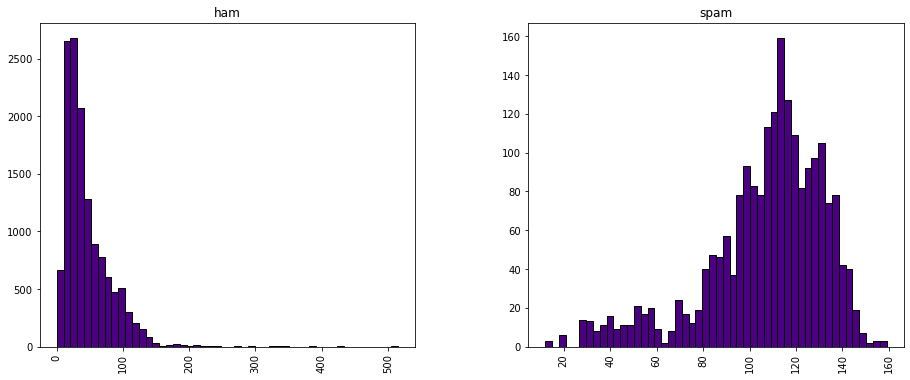

In [6]:
result['length'] = result['text'].apply(len)
result.hist(column='length',by='label',bins=50, color='indigo', edgecolor='black', figsize=(15,6))

### Step 2, Part 3: Encode categories and use bag of words for creating clean column attributes for the text ###

In [7]:
#Categorical encoding
# result['label'] = result['label'].astype('category')
# result['isSpam'] = result['label'].cat.codes

result['label'].value_counts(normalize=True)

#Bag of words/ clean list of text words || Future proofing
data = result['text'].str.split()

vocabulary = []
for text in data:
    for word in text:
        vocabulary.append(word)

vocabulary = list(set(vocabulary))


word_counts_per_text = {unique_word: [0] * len(data) for unique_word in vocabulary}

for index, text in enumerate(data):
    for word in text:
        word_counts_per_text[word][index] += 1

word_counts = pd.DataFrame(word_counts_per_text)
word_counts

,network,serious,field,gut,permanent,62220cncl,loan,dismissial,enufcredeit,gal,...,ts,stops,pickle,inner,lies,08719181503,mentionned,61610,pimples,thekingshead
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15586,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15587,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15588,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Step 2, Part 4: Create final training dataset ###

In [8]:
#Combine words dataframe with training set
training_result_df = pd.merge(result, word_counts, left_index=True, right_index=True)
training_result_df.head()

,label,text_x,length_x,network,serious,field,gut,permanent,62220cncl,loan,...,ts,stops,pickle,inner,lies,08719181503,mentionned,61610,pimples,thekingshead
0,ham,hope good week checking,23,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,spam,u outbid simonwatson5120 shinco dvd plyr 2 bid...,103,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,ham,go jurong point crazy available bugis n great ...,82,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,kgive back thanks,17,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,still grinder,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 3:- Visualise the data[20 points]
#### Try to visualize and analyse the data such as before and after pre processing, number of ham/spam etc. Analyse as many verticals you can, feel free to use graphical libraries like seaborn.

Text(0.5, 1.0, 'TrainDataset2')

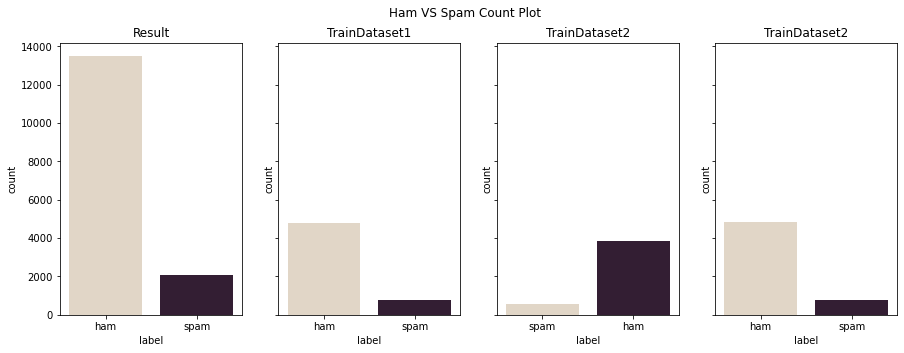

In [9]:
#Visualise the data   

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
fig.suptitle('Ham VS Spam Count Plot')

sns.countplot(ax=axes[0], x = 'label', data = training_result_df, palette = "ch:.25")
axes[0].set_title('Result')

sns.countplot(ax=axes[1], x = 'label', data = train1, palette = "ch:.25")
axes[1].set_title('TrainDataset1')

sns.countplot(ax=axes[2], x = 'label', data = train2, palette = "ch:.25")
axes[2].set_title('TrainDataset2')

sns.countplot(ax=axes[3], x = 'label', data = train3, palette = "ch:.25")
axes[3].set_title('TrainDataset2')

## Step 4:- Build, train and validate the classifer, [20 points]

### Training on supervised data (labelled data)

#### Use the data in order to build your own Naive Bayes classifier (You can either use existing Naive Bayes from sklearn or build your own). Build the classifier, train it and then validate. Provide your result in confusion matrix (use heatmap from seaborn) along with the classification report from sklearn. Validation accuracy should be around 99%.

#### Train and fit and predict #### 

In [10]:
# Build, train and validate the classifier, 
x_train, x_valid, y_train, y_valid = train_test_split(result['text'], result['label'], test_size=0.2)

pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=preProcessing)), # converts strings to integer counts
    ('tfidf', TfidfTransformer()), # converts integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()) # train on TF-IDF vectors with Naive Bayes classifier
])

pipeline.fit(x_train, y_train)

y_predictions = pipeline.predict(x_valid)

#### Report: ###

In [11]:
print("Classification Report: \n")
print(classification_report(y_valid, y_predictions))

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_valid, y_predictions)))

Classification Report: 

              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      2705
        spam       0.94      0.77      0.84       413

    accuracy                           0.96      3118
   macro avg       0.95      0.88      0.91      3118
weighted avg       0.96      0.96      0.96      3118

Model accuracy score: 0.9625


#### Confusion Matrix: ####


 Confusion Matrix: 



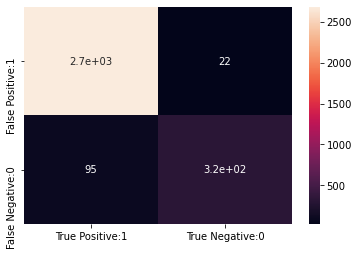

In [12]:
print("\n Confusion Matrix: \n")
cm = confusion_matrix(y_valid, y_predictions)
cm_matrix = pd.DataFrame(data = cm, columns = ['True Positive:1', 'True Negative:0'], index = ['False Positive:1', 'False Negative:0'])
sns.heatmap(cm_matrix, annot=True)

## Step 5:- Test the classifier[10 points]

### Supervised classification[5 points] 

#### Test your Classifier using  the SMSSpamCollection.txt dataset provide a heatmap and classification report. Test accuracy should be around 99%.


Classification Report: 

              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      4825
        spam       0.96      0.77      0.85       747

    accuracy                           0.96      5572
   macro avg       0.96      0.88      0.92      5572
weighted avg       0.96      0.96      0.96      5572

Model accuracy score: 0.9645

 Confusion Matrix: 



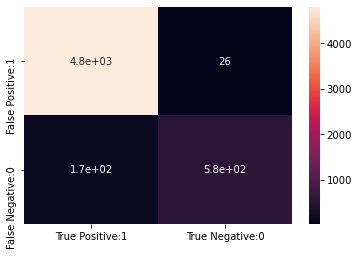

In [13]:
### Test the classifier

sms = pd.read_csv('SMSSpamCollection.txt', sep="\t", header = None)
sms.columns = ['label', 'text']

sms_text = sms['text']
sms_label = sms['label']

sms_predictions = pipeline.predict(sms_text)

print("Classification Report: \n")
print(classification_report(sms_label, sms_predictions))

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(sms_label, sms_predictions)))

print("\n Confusion Matrix: \n")
cm = confusion_matrix(sms_label, sms_predictions)
cm_matrix = pd.DataFrame(data = cm, columns = ['True Positive:1', 'True Negative:0'], index = ['False Positive:1', 'False Negative:0'])
sns.heatmap(cm_matrix, annot=True)

### Unsupervised classification[5 points] 

#### Test your Classifier using  the TestDataset.csv dataset. This dataset is not labelled so kindly predict the labels and visualise it[5 points].

In [14]:
# Test the classifier

test_set = pd.read_csv('TestDataset.csv')

predictions = pipeline.predict(test_set['v2'])
test_set.insert(0, "label", predictions, True) 
test_set

,label,v2
0,ham,Prabha..i'm soryda..realy..frm heart i'm sory
1,ham,"Jus chillaxin, what up"
2,ham,Ok no prob. Take ur time.
3,spam,Congrats! 2 mobile 3G Videophones R yours. cal...
4,ham,Thankyou so much for the call. I appreciate yo...
...,...,...
1110,ham,Yo chad which gymnastics class do you wanna ta...
1111,ham,God created gap btwn ur fingers so dat sum1 vr...
1112,ham,I'm working technical support :)voice process.
1113,ham,I told your number to gautham..


## Step 6:- Cheat the classifier[20 points]

#### Try to cheat the classifier by adding "good words" to the end of test dataset(TestDataset.csv) e.g:- Oh! no share Market has fallen down by $100,000 due to Corona outbreak... try mixing up spam and ham words see how the classifier works. Output the results in a good format to validate your work[15 points]  

In [15]:
# Cheat the classifier
new_df = pd.DataFrame()

spams = sms.loc[sms['label'] == 'spam']

for i in range(6):
    # append the multiple rows
    new_df = new_df.append(spams.iloc[i], ignore_index=True)

new_df['label'] = 'ham'
new_df.head()
new_df.columns = ['label', 'v2']
new_df.tail()

test_set.tail()

test_set.loc[1110].at['v2'] = new_df.loc[3].at['v2'] + test_set.loc[1110].at['v2']  
test_set.loc[1111].at['v2'] = test_set.loc[1111].at['v2'] + new_df.loc[4].at['v2'] 
test_set.loc[1112].at['v2'] =  new_df.loc[5].at['v2'] + test_set.loc[1112].at['v2'] 
test_set.loc[1113].at['v2'] = test_set.loc[1113].at['v2'] + new_df.loc[2].at['v2'] 
test_set.loc[1114].at['v2'] = new_df.loc[1].at['v2'] + test_set.loc[1114].at['v2']

test_set.tail()

,label,v2
1110,ham,Had your mobile 11 months or more? U R entitle...
1111,ham,God created gap btwn ur fingers so dat sum1 vr...
1112,ham,URGENT! You have won a 1 week FREE membership ...
1113,ham,I told your number to gautham..WINNER!! As a v...
1114,ham,FreeMsg Hey there darling it's been 3 week's n...


In [16]:
cheat_predictions = pipeline.predict(test_set['v2'])
test_set.insert(2, "predictions", cheat_predictions, True) 
test_set.tail()

# print('Model accuracy score: {0:0.4f}'. format(accuracy_score(spams, cheat_predictions)))

,label,v2,predictions
1110,ham,Had your mobile 11 months or more? U R entitle...,ham
1111,ham,God created gap btwn ur fingers so dat sum1 vr...,spam
1112,ham,URGENT! You have won a 1 week FREE membership ...,spam
1113,ham,I told your number to gautham..WINNER!! As a v...,spam
1114,ham,FreeMsg Hey there darling it's been 3 week's n...,ham


#### Write your analysis of how you intended to cheat the classifier and how it performed in few words (provide your inference)[5 points]

My approach was collecting spam text from SMSSpamCollection changing all their labels to be "ham". I appended the sentences randomly to to test_set. In some instances, the classifier was able to recognize spam. In others, not much.

### Help

<a href="https://towardsdatascience.com/spam-filtering-using-naive-bayes-98a341224038" target="_top">Spam classification</a><br>
<a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_top">Seaborn Heatmap</a><br>
<a href="https://scikit-learn.org/stable/modules/naive_bayes.html" target="_top">Sklearn Naive Bayes</a><br>
<a href="https://scikit-learn.org/stable/modules/model_evaluation.html" target="_top">Sklearn Metrics</a><br>
<a href="https://pandas.pydata.org/docs/getting_started/index.html#getting-started" target="_top">Intro to Pandas</a>